<a href="https://colab.research.google.com/github/IT24100378/ToxicCommentNLPfinal/blob/Remove-punctuation-and-special-characters/Removing_Punctuations_and_Special_Characters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
file_path = "train_preprocessed_lowercased.csv"  # update path if needed
df = pd.read_csv(file_path)

# Display first five rows
df.head()


,comment_text,toxic
0,"""\r\n\r\n """"lighten up, francis"""" \r\n\r\non s...",0
1,lisa williams is a total fraud \r\nno offense ...,1
2,"i am david in dc, not davidindc. on at least o...",1
3,fuck you \r\n\r\n \r\nfuck you keep blocking ...,1
4,"both entries are on the same subject, they sho...",0


Shape of dataset: (16000, 2)

Missing values:
 comment_text    0
toxic           0
dtype: int64

Class distribution:
 toxic
0    8000
1    8000
Name: count, dtype: int64


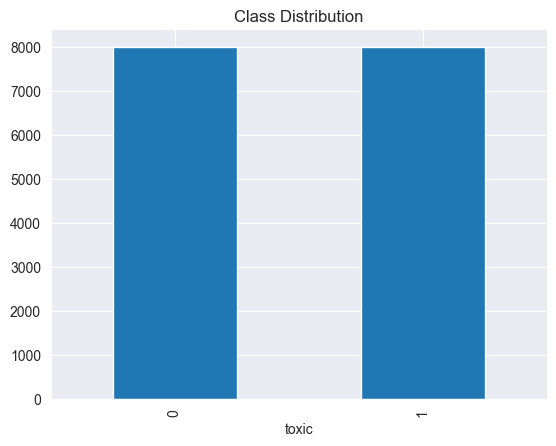

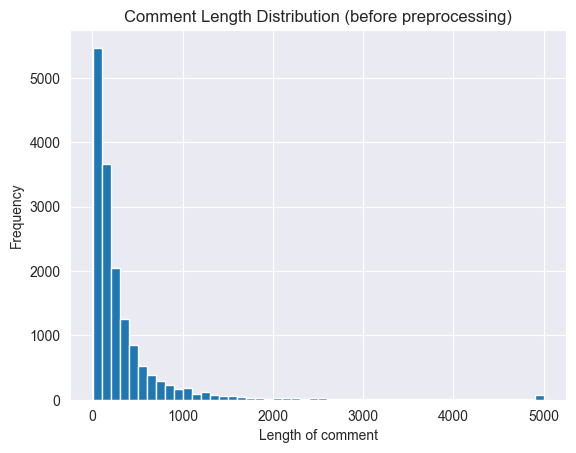

,comment_text,toxic
0,"""\r\n\r\n """"lighten up, francis"""" \r\n\r\non s...",0
1,lisa williams is a total fraud \r\nno offense ...,1
2,"i am david in dc, not davidindc. on at least o...",1
3,fuck you \r\n\r\n \r\nfuck you keep blocking ...,1
4,"both entries are on the same subject, they sho...",0


In [2]:
#EDA BEFORE PREPROCESSING
import matplotlib.pyplot as plt

# Shape of dataset
print("Shape of dataset:", df.shape)

# Check null values
print("\nMissing values:\n", df.isnull().sum())

# Class distribution
print("\nClass distribution:\n", df['toxic'].value_counts())

df['toxic'].value_counts().plot(kind='bar', title='Class Distribution')
plt.show()

# Comment length analysis
df['comment_length'] = df['comment_text'].astype(str).apply(len)
df['comment_length'].hist(bins=50)
plt.title("Comment Length Distribution (before preprocessing)")
plt.xlabel("Length of comment")
plt.ylabel("Frequency")
plt.show()

# Display some examples
df[['comment_text', 'toxic']].head()


In [3]:
#Preprocessing remove punctuations and special characters
import re

def clean_text(text):
    # Remove punctuation & special characters, keep only letters/numbers/spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text))
    return text

# Apply cleaning
df['cleaned_comment'] = df['comment_text'].apply(clean_text)

# Show examples before vs after
df[['comment_text', 'cleaned_comment']].head()


,comment_text,cleaned_comment
0,"""\r\n\r\n """"lighten up, francis"""" \r\n\r\non s...",\r\n\r\n lighten up francis \r\n\r\non same te...
1,lisa williams is a total fraud \r\nno offense ...,lisa williams is a total fraud \r\nno offense ...
2,"i am david in dc, not davidindc. on at least o...",i am david in dc not davidindc on at least one...
3,fuck you \r\n\r\n \r\nfuck you keep blocking ...,fuck you \r\n\r\n \r\nfuck you keep blocking ...
4,"both entries are on the same subject, they sho...",both entries are on the same subject they shou...


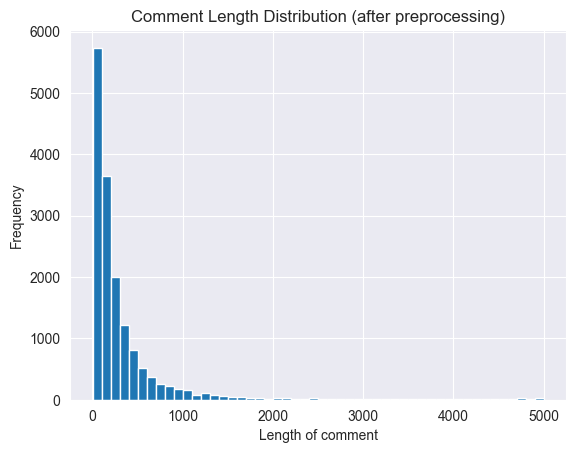

,cleaned_comment,toxic
0,\r\n\r\n lighten up francis \r\n\r\non same te...,0
1,lisa williams is a total fraud \r\nno offense ...,1
2,i am david in dc not davidindc on at least one...,1
3,fuck you \r\n\r\n \r\nfuck you keep blocking ...,1
4,both entries are on the same subject they shou...,0


In [4]:
#EDA AFTER PREPROCESSING
# Comment length distribution after cleaning
df['cleaned_length'] = df['cleaned_comment'].astype(str).apply(len)
df['cleaned_length'].hist(bins=50)
plt.title("Comment Length Distribution (after preprocessing)")
plt.xlabel("Length of comment")
plt.ylabel("Frequency")
plt.show()

# Display first few cleaned comments
df[['cleaned_comment', 'toxic']].head()


In [14]:

# Keep only required columns
final_df = df[['cleaned_comment', 'toxic']]

# Save to CSV
output_path = "data/PunctCleanedDataset.csv"
final_df.to_csv(output_path, index=False)

print(f"File saved successfully at: {output_path}")




File saved successfully at: data/PunctCleanedDataset.csv
